In [1]:
#Dependencies Required

!pip install ipympl

!pip install numpy matplotlib

# %pip install ipympl
%matplotlib widget




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

## Step 1 — Environment + Initial State S₀

In [3]:
def initial_state():
    return np.zeros((3, 3), dtype=int)

S0 = initial_state()
print("S0 (initial state):")
print(S0)

S0 (initial state):
[[0 0 0]
 [0 0 0]
 [0 0 0]]


## Step 2 — State Description

STATE  s  =  board  (3×3 numpy int array)

  board[r, c] values:
  
      0  →  empty cell
      
      1  →  X  (Maximizer — wants UTILITY = +1)
      
     -1  →  O  (Minimizer — wants UTILITY = -1)
     

  r = row 0..2 (top → bottom)
  
  c = col 0..2 (left → right)

Formal functions:

  PLAYER(s)       → who moves next (1 or -1)
  
  ACTIONS(s)      → list of legal (r,c) moves
  
  RESULT(s, a)    → new state after action a
  
  TERMINAL(s)     → True if game over
  
  UTILITY(s)      → +1 (X wins) | -1 (O wins) | 0 (draw)

Terminal conditions:

  • Any row, col, or diagonal all same non-zero value
  
  • Board full with no winner → draw

In [4]:
def PLAYER(board):
    """X moves first. After each X move, O moves. Count pieces to decide."""
    x_count = np.sum(board == 1)
    o_count = np.sum(board == -1)
    return 1 if x_count == o_count else -1  # X if equal counts, else O


def ACTIONS(board):
    """All empty cells are legal moves."""
    return [(r, c) for r in range( 3) for c in range(3) if board[r, c] == 0]


def RESULT(board, action):
    """Apply action; returns new board (original unchanged)."""
    r, c = action
    new_board = board.copy()
    new_board[r, c] = PLAYER(board)
    return new_board


def _winner(board):
    """Returns winning player (1 or -1) or None."""
    for p in [1, -1]:
        for i in range(3):
            if all(board[i, :] == p) or all(board[:, i] == p): # vertical ra horizontal ma same
                return p
        if board[0,0] == board[1,1] == board[2,2] == p: # diagonal cha ki chaina
            return p
        if board[0,2] == board[1,1] == board[2,0] == p: # diagonal cha ki chaina
            return p
    return None


def TERMINAL(board):
    """Game over if there's a winner OR no moves left."""
    return _winner(board) is not None or len(ACTIONS(board)) == 0


def UTILITY(board):
    """Only meaningful on terminal states."""
    w = _winner(board)
    return w if w is not None else 0


test = np.array([[1, 1, 1],
                 [0,-1,-1],
                 [0, 0, 0]])
print("Test board:")
print(test)
print(f"  TERMINAL: {TERMINAL(test)}")
print(f"  UTILITY:  {UTILITY(test)}   ← X wins (+1)")
print(f"  PLAYER(S0): {'X' if PLAYER(S0)==1 else 'O'}   ← X goes first")

Test board:
[[ 1  1  1]
 [ 0 -1 -1]
 [ 0  0  0]]
  TERMINAL: True
  UTILITY:  1   ← X wins (+1)
  PLAYER(S0): X   ← X goes first


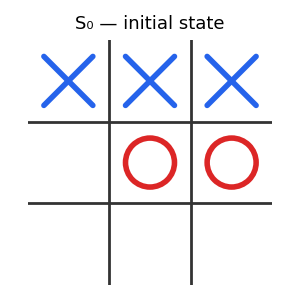

In [5]:
def draw_board(ax, board, title=""):
    ax.clear()
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor('#f7f7f7')

    # grid lines
    for i in range(1, 3):
        ax.axvline(i, color='#333333', lw=2)
        ax.axhline(i, color='#333333', lw=2)

    # pieces
    for r in range(3):
        for c in range(3):
            # board row 0 = top, but matplotlib y=0 = bottom
            # so center_y = 2.5 - r
            cx, cy = c + 0.5, 2.5 - r
            if board[r, c] == 1:   # X — blue cross
                ax.plot([cx-0.3, cx+0.3], [cy-0.3, cy+0.3], color='#2563eb', lw=4, solid_capstyle='round')
                ax.plot([cx-0.3, cx+0.3], [cy+0.3, cy-0.3], color='#2563eb', lw=4, solid_capstyle='round')
            elif board[r, c] == -1:  # O — red circle
                circ = Circle((cx, cy), 0.3, fill=False, edgecolor='#dc2626', lw=4)
                ax.add_patch(circ)

    if title:
        ax.set_title(title, fontsize=13, pad=8)


# preview empty board
fig0, ax0 = plt.subplots(figsize=(3, 3))
draw_board(ax0, test, "S₀ — initial state")
plt.tight_layout()
plt.show()



## Step 3 — Clickable Human vs Human

Click any empty cell to place a piece.

X (blue) moves first, O (red) second.

Run the Reset cell below to restart.

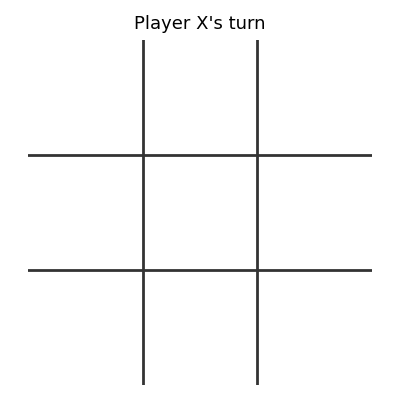

In [6]:
board_hvh = initial_state()

fig_hvh, ax_hvh = plt.subplots(figsize=(4, 4))
fig_hvh.canvas.header_visible = False
draw_board(ax_hvh, board_hvh, "Player X's turn")

def _status_hvh():
    if not TERMINAL(board_hvh):
        p = PLAYER(board_hvh)
        return f"Player {'X' if p == 1 else 'O'}'s turn"
    u = UTILITY(board_hvh)
    if u == 1:  return "X wins!"
    if u == -1: return "O wins!"
    return "Draw!"

def onclick_hvh(event):
    global board_hvh
    if event.inaxes != ax_hvh:
        return
    if TERMINAL(board_hvh):
        return

    x, y = event.xdata, event.ydata
    if x is None or y is None:
        return
    if not (0 <= x < 3 and 0 <= y < 3):
        return

    c = int(x)
    r = 2 - int(y)  # flip: matplotlib y=0 is bottom, board row 0 is top

    if board_hvh[r, c] != 0:
        return  # cell occupied

    board_hvh = RESULT(board_hvh, (r, c))
    draw_board(ax_hvh, board_hvh, _status_hvh())
    fig_hvh.canvas.draw()

fig_hvh.canvas.mpl_connect('button_press_event', onclick_hvh)
plt.tight_layout()
plt.show()

## Step 4 — Minimax Algorithm
MINIMAX(s):

  if TERMINAL(s): return UTILITY(s)
  
  if PLAYER(s) == X (MAX):           ← wants highest value
  
    return max over a in ACTIONS(s): MINIMAX(RESULT(s,a))
    
  if PLAYER(s) == O (MIN):           ← wants lowest value
  
    return min over a in ACTIONS(s): MINIMAX(RESULT(s,a))
    
Tic-tac-toe has at most 9! = 362880 leaf nodes — exhaustive search is fast.

In [7]:
def minimax(board):
    """
    Returns (value, best_action).
    value    : +1 / 0 / -1 from current player's optimal play
    best_action: (r, c) or None on terminal
    """
    if TERMINAL(board):
        return UTILITY(board), None

    player = PLAYER(board)

    if player == 1:  # X — Maximizer
        best_val = -float('inf')
        best_action = None
        for action in ACTIONS(board):
            val, _ = minimax(RESULT(board, action))
            if val > best_val:
                best_val, best_action = val, action
        return best_val, best_action

    else:            # O — Minimizer
        best_val = float('inf')
        best_action = None
        for action in ACTIONS(board):
            val, _ = minimax(RESULT(board, action))
            if val < best_val:
                best_val, best_action = val, action
        return best_val, best_action


val, action = minimax(S0)
print(f"From S0: best move = {action}, minimax value = {val}")
print("(value 0 → perfect play leads to draw from both sides)")



From S0: best move = (0, 0), minimax value = 0
(value 0 → perfect play leads to draw from both sides)


## Human (X) vs Minimax AI (O)

You play X (click to move).

AI plays O — it is unbeatable (minimax = optimal).

Best you can achieve is a draw.

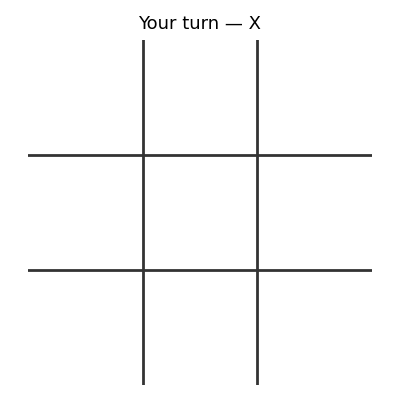

In [16]:
board_hva = initial_state()

fig_hva, ax_hva = plt.subplots(figsize=(4, 4))
fig_hva.canvas.header_visible = False
draw_board(ax_hva, board_hva, "Your turn — X")

def _status_hva():
    if not TERMINAL(board_hva):
        p = PLAYER(board_hva)
        return "Your turn — X" if p == 1 else "AI thinking..."
    u = UTILITY(board_hva)
    if u == 1:  return "You win! (impossible vs minimax)"
    if u == -1: return "AI wins."
    return "Draw — well played."

def onclick_hva(event):
    global board_hva
    if event.inaxes != ax_hva:
        return
    if TERMINAL(board_hva):
        return
    if PLAYER(board_hva) != 1:  # not human's turn
        return

    x, y = event.xdata, event.ydata
    if x is None or y is None:
        return
    if not (0 <= x < 3 and 0 <= y < 3):
        return

    c = int(x)
    r = 2 - int(y)

    if board_hva[r, c] != 0:
        return

    # --- human move ---
    board_hva = RESULT(board_hva, (r, c))

    if TERMINAL(board_hva):
        draw_board(ax_hva, board_hva, _status_hva())
        fig_hva.canvas.draw()
        return

    # --- AI move (Minimax) ---
    _, ai_action = minimax(board_hva)   # O minimizes
    board_hva = RESULT(board_hva, ai_action)

    draw_board(ax_hva, board_hva, _status_hva())
    fig_hva.canvas.draw()

fig_hva.canvas.mpl_connect('button_press_event', onclick_hva)
plt.tight_layout()
plt.show()
